In [ ]:
import pandas as pd

df = pd.read_csv("styles.csv", on_bad_lines='skip')

print(df.head())
print(df.isnull().sum())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0

In [ ]:
# Drop rows with important missing values
df = df.dropna(subset=['usage', 'baseColour', 'season', 'productDisplayName'])

# Convert year to int
df['year'] = df['year'].fillna(0).astype(int)

# Reset index
df = df.reset_index(drop=True)

print(df.isnull().sum())
print(df.shape)

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64
(44077, 10)


In [ ]:
# Remove duplicates in each transaction
transactions = df.groupby(['gender', 'usage'])['articleType'] \
                 .apply(lambda x: list(set(x)))

# Convert to list
transactions = transactions.tolist()

# Show sample
for i in range(5):
    print(transactions[i])

['Jeans', 'Rompers', 'Trousers', 'Sweatshirts', 'Shorts', 'Jackets', 'Booties', 'Capris', 'Blazers', 'Flip Flops', 'Sunglasses', 'Innerwear Vests', 'Watches', 'Waistcoat', 'Casual Shoes', 'Sandals', 'Tshirts', 'Clothing Set', 'Gloves', 'Shirts', 'Leggings', 'Socks']
['Kurtas', 'Churidar', 'Kurta Sets']
['Sports Shoes', 'Tshirts', 'Caps', 'Shorts']
['Skirts', 'Dresses', 'Jeans', 'Rompers', 'Trousers', 'Shorts', 'Booties', 'Capris', 'Tops', 'Flip Flops', 'Sunglasses', 'Innerwear Vests', 'Backpacks', 'Watches', 'Casual Shoes', 'Sandals', 'Tshirts', 'Clothing Set', 'Gloves', 'Shirts', 'Leggings']
['Salwar', 'Lehenga Choli', 'Earrings']


# Data Convert (Apriori format)


One-hot encoded data


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_apriori = pd.DataFrame(te_array, columns=te.columns_)

print(df_apriori.head())

   Accessory Gift Set  Baby Dolls  Backpacks  Bangle  Basketballs  Bath Robe  \
0               False       False      False   False        False      False   
1               False       False      False   False        False      False   
2               False       False      False   False        False      False   
3               False       False       True   False        False      False   
4               False       False      False   False        False      False   

   Beauty Accessory  Belts  Blazers  Body Lotion  ...  Trunk  Tshirts  Tunics  \
0             False  False     True        False  ...  False     True   False   
1             False  False    False        False  ...  False    False   False   
2             False  False    False        False  ...  False     True   False   
3             False  False    False        False  ...  False     True   False   
4             False  False    False        False  ...  False    False   False   

   Umbrellas  Waist Pouch  Waist

In [ ]:
sdf

NameError: name 'sdf' is not defined

Apriori Algorithm


In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_apriori, min_support=0.1, use_colnames=True)

print(frequent_itemsets.head())

KeyboardInterrupt: 

Association Rules


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print(rules[['antecedents', 'consequents', 'support', 'confidence']].head())

new


In [ ]:
# Step 1: Filter items

valid_items = ['Tshirts', 'Shirts', 'Jeans', 'Shoes', 'Trousers', 'Shorts']

transactions = df.groupby(['gender', 'usage'])['articleType'] \
                 .apply(lambda x: list(set([i for i in x if i in valid_items])))

transactions = transactions.tolist()

In [ ]:


# Step 2: Encode
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_apriori = pd.DataFrame(te_array, columns=te.columns_)

# Step 3: Apriori (SAFE)
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df_apriori, 
                           min_support=0.05, 
                           max_len=2, 
                           use_colnames=True)

print(frequent_itemsets)

    support                        itemsets
0      0.20              frozenset({Jeans})
1      0.40             frozenset({Shirts})
2      0.28             frozenset({Shorts})
3      0.32           frozenset({Trousers})
4      0.44            frozenset({Tshirts})
5      0.16      frozenset({Shirts, Jeans})
6      0.16      frozenset({Jeans, Shorts})
7      0.16    frozenset({Jeans, Trousers})
8      0.20     frozenset({Jeans, Tshirts})
9      0.16     frozenset({Shirts, Shorts})
10     0.28   frozenset({Shirts, Trousers})
11     0.24    frozenset({Shirts, Tshirts})
12     0.16   frozenset({Shorts, Trousers})
13     0.28    frozenset({Shorts, Tshirts})
14     0.24  frozenset({Tshirts, Trousers})


Association Rules


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, 
                          metric="confidence", 
                          min_threshold=0.3)

print(rules[['antecedents', 'consequents', 'support', 'confidence']])

              antecedents            consequents  support  confidence
0     frozenset({Shirts})     frozenset({Jeans})     0.16    0.400000
1      frozenset({Jeans})    frozenset({Shirts})     0.16    0.800000
2      frozenset({Jeans})    frozenset({Shorts})     0.16    0.800000
3     frozenset({Shorts})     frozenset({Jeans})     0.16    0.571429
4      frozenset({Jeans})  frozenset({Trousers})     0.16    0.800000
5   frozenset({Trousers})     frozenset({Jeans})     0.16    0.500000
6      frozenset({Jeans})   frozenset({Tshirts})     0.20    1.000000
7    frozenset({Tshirts})     frozenset({Jeans})     0.20    0.454545
8     frozenset({Shirts})    frozenset({Shorts})     0.16    0.400000
9     frozenset({Shorts})    frozenset({Shirts})     0.16    0.571429
10    frozenset({Shirts})  frozenset({Trousers})     0.28    0.700000
11  frozenset({Trousers})    frozenset({Shirts})     0.28    0.875000
12    frozenset({Shirts})   frozenset({Tshirts})     0.24    0.600000
13   frozenset({Tshi

In [ ]:
def recommend_outfit(item_name, rules, top_n=5):
    filtered = rules[rules['antecedents'].apply(lambda x: item_name in x)]
    
    filtered = filtered.sort_values(by='confidence', ascending=False)

    recommendations = []
    for cons in filtered['consequents']:
        recommendations.extend(list(cons))

    return list(set(recommendations))[:top_n]

In [ ]:
print(recommend_outfit('Tshirts', rules))
print(recommend_outfit('Shirts', rules))

['Shirts', 'Shorts', 'Trousers', 'Jeans']
['Jeans', 'Tshirts', 'Shorts', 'Trousers']


# Content-Based Recommender


In [ ]:
# Combine features into one text column
df['text'] = df['articleType'] + " " + df['baseColour'] + " " + df['usage']

print(df[['text']].head())

                       text
0   Shirts Navy Blue Casual
1         Jeans Blue Casual
2     Watches Silver Casual
3  Track Pants Black Casual
4       Tshirts Grey Casual


TF-IDF Vectorization


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['text'])

print(tfidf_matrix.shape)

(44077, 219)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [ ]:
def recommend_similar(item_index, top_n=5):
    sim_scores = list(enumerate(cosine_sim[item_index]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]

    item_indices = [i[0] for i in sim_scores]

    return df['productDisplayName'].iloc[item_indices]

In [ ]:
print(df['productDisplayName'][0])  # Input item

print(recommend_similar(0))

Turtle Check Men Navy Blue Shirt
289     Indigo Nation Men Club Satin Hot Stepper Navy ...
379       Indigo Nation Men Checks Shirt Navy Blue Shirts
732        Scullers For Her Women Printed Navy Blue Shirt
899                                 Basics Men Navy Shirt
1196             Arrow Sport Men Printed Navy Blue Shirts
Name: productDisplayName, dtype: str


Hybrid Function


In [ ]:
def hybrid_recommend(item_index, item_name, rules, top_n=5):
    
    # 🔹 1. Content-based (TF-IDF)
    sim_scores = list(enumerate(cosine_sim[item_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    content_items = [df['productDisplayName'].iloc[i[0]] for i in sim_scores]

    # 🔹 2. Apriori (Outfit)
    apriori_items = recommend_outfit(item_name, rules)

    return {
        "Similar Items": content_items,
        "Outfit Recommendations": apriori_items
    }

In [ ]:
def display_output(item_index, item_name, result):
    
    print("="*60)
    print("👕 FASHION RECOMMENDER SYSTEM")
    print("="*60)
    
    print(f"\n🔹 Selected Item:")
    print(f"👉 {df['productDisplayName'][item_index]}")
    
    print("\n🔹 Similar Items (Content-Based):")
    for i, item in enumerate(result['Similar Items'], 1):
        print(f"{i}. {item}")
    
    print("\n🔹 Outfit Recommendations (Apriori):")
    for i, item in enumerate(result['Outfit Recommendations'], 1):
        print(f"{i}. {item}")
    
    print("\n" + "="*60)

In [ ]:
result = hybrid_recommend(0, 'Shirts', rules)

display_output(0, 'Shirts', result)

👕 FASHION RECOMMENDER SYSTEM

🔹 Selected Item:
👉 Turtle Check Men Navy Blue Shirt

🔹 Similar Items (Content-Based):
1. Indigo Nation Men Club Satin Hot Stepper Navy Blue Shirt
2. Indigo Nation Men Checks Shirt Navy Blue Shirts
3. Scullers For Her Women Printed Navy Blue Shirt
4. Basics Men Navy Shirt
5. Arrow Sport Men Printed Navy Blue Shirts

🔹 Outfit Recommendations (Apriori):
1. Trousers
2. Jeans
3. Tshirts
4. Shorts



# Image Display


In [ ]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

def show_image(item_id):
    img_path = f"images/{item_id}.jpg"
    
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        print("Image not found")

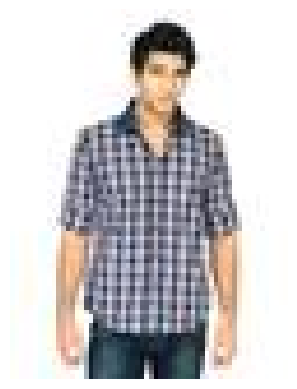

In [ ]:
show_image(df['id'][0])

In [ ]:

def show_multiple_images(indices):
    import matplotlib.pyplot as plt
    import cv2
    import os

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(indices):
        img_id = df['id'].iloc[idx]
        img_path = f"images/{img_id}.jpg"

        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(indices), i+1)
            plt.imshow(img)
            plt.title(df['articleType'].iloc[idx])
            plt.axis('off')

    plt.show()

In [ ]:
def get_similar_indices(item_index, top_n=5):
    sim_scores = list(enumerate(cosine_sim[item_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    return [i[0] for i in sim_scores]

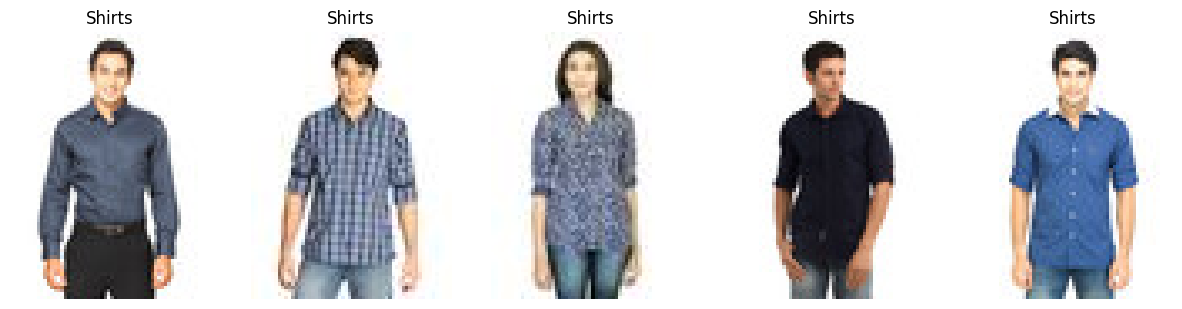

In [ ]:
similar_indices = get_similar_indices(0)

show_multiple_images(similar_indices)

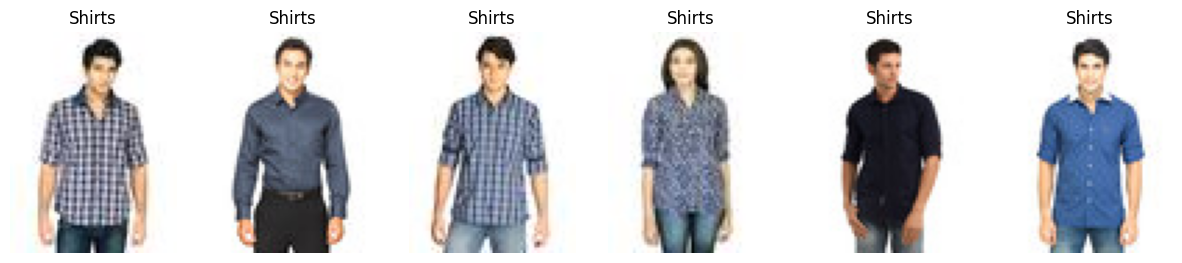

In [ ]:
all_indices = [0] + similar_indices
show_multiple_images(all_indices)

In [ ]:
def black_pants_recommend(top_n=5):
    filtered = df[
        (df['baseColour'] == 'Black') &
        (df['articleType'].isin(['Jeans', 'Trousers']))
    ]
    
    return filtered[['productDisplayName']].head(top_n)

In [ ]:
print(black_pants_recommend())

                            productDisplayName
116               Jealous 21 Women Black Jeans
164  John Miller Men Solid Type Black Trousers
202             Jealous 21 Women Black Jegging
376     Jealous 21 Women's Aaren Black Jegging
455        Peter England Men Party Black Jeans


In [ ]:
def show_black_pants(top_n=5):
    filtered = df[
        (df['baseColour'] == 'Black') &
        (df['articleType'].isin(['Jeans', 'Trousers']))
    ].head(top_n)

    indices = filtered.index.tolist()
    show_multiple_images(indices)

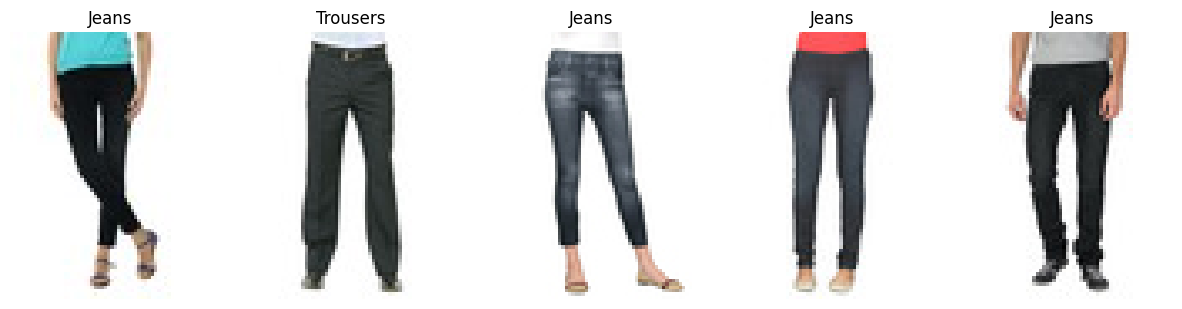

In [ ]:
show_black_pants()

In [ ]:
def smart_black_pants(gender='Men', usage='Casual', top_n=5):
    filtered = df[
        (df['baseColour'] == 'Black') &
        (df['articleType'].isin(['Jeans', 'Trousers'])) &
        (df['gender'] == gender) &
        (df['usage'] == usage)
    ]
    
    return filtered['productDisplayName'].head(top_n)

In [ ]:
print(smart_black_pants())

455         Peter England Men Party Black Jeans
971               Peter England Men Black Jeans
1136                  Basics Men Black Trousers
1439                  Basics Men Black Trousers
1978    French Connection Men Charcoal Trousers
Name: productDisplayName, dtype: str


# Now take user input


In [ ]:
def user_recommend():
    item = input("Enter item (e.g. Tshirts, Shirts): ")
    
    result = recommend_outfit(item, rules)
    
    print("\nRecommended Outfit:")
    for i, r in enumerate(result, 1):
        print(f"{i}. {r}")

In [ ]:
user_recommend()


Recommended Outfit:


Smart Input Parser

👉 User jo bhi likhe → system samjhe


In [ ]:
def parse_input(user_input):
    user_input = user_input.lower()
    
    color = None
    item = None

    # detect color
    colors = df['baseColour'].dropna().unique()
    for c in colors:
        if c.lower() in user_input:
            color = c
            break

    # detect item
    items = df['articleType'].dropna().unique()
    for i in items:
        if i.lower() in user_input:
            item = i
            break

    return color, item

Upper + Lower Recommendation


In [ ]:
def recommend_full_outfit(color, item, top_n=5):
    
    # Upper (same item)
    upper = df[
        (df['baseColour'] == color) &
        (df['articleType'] == item)
    ].head(top_n)

    # Lower (pants)
    lower = df[
        (df['baseColour'] == color) &
        (df['articleType'].isin(['Jeans', 'Trousers']))
    ].head(top_n)

    return upper, lower

Show Images Properly


In [ ]:
def show_section(title, data):
    import matplotlib.pyplot as plt
    import cv2
    import os

    print(f"\n🔹 {title}")

    plt.figure(figsize=(12,4))

    for i, idx in enumerate(data.index):
        img_id = df.loc[idx, 'id']
        path = f"images/{img_id}.jpg"

        if os.path.exists(path):
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(data), i+1)
            plt.imshow(img)
            plt.title(df.loc[idx, 'articleType'])
            plt.axis('off')

    plt.show()

FINAL SYSTEM


In [ ]:
def smart_fashion_recommender():
    user_input = input("Enter your choice (e.g. Black shirt): ")

    color, item = parse_input(user_input)

    if color is None or item is None:
        print("Could not understand input")
        return

    upper, lower = recommend_full_outfit(color, item)

    print("\n==============================")
    print(f"INPUT: {user_input}")
    print("==============================")

    show_section("Matching Upper Wear", upper)
    show_section("Matching Bottom Wear", lower)


INPUT: Black T-Shirts

🔹 Matching Upper Wear


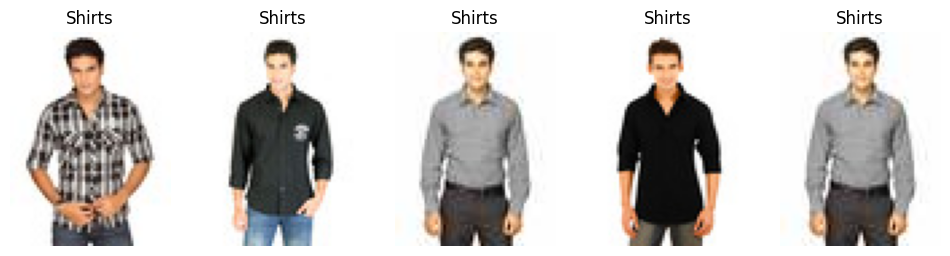


🔹 Matching Bottom Wear


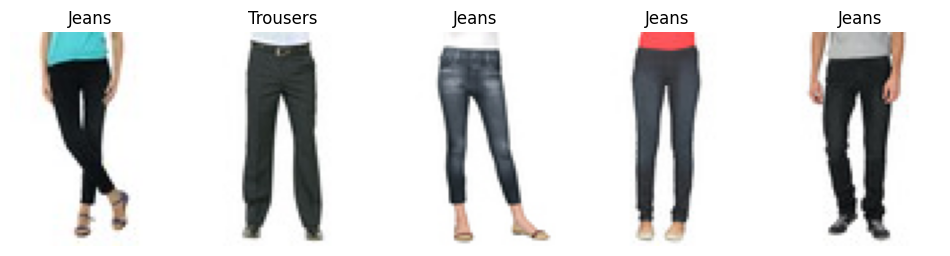

In [ ]:
smart_fashion_recommender()

In [ ]:
def normalize_input(user_input):
    user_input = user_input.lower()

    # fix spelling mistakes
    user_input = user_input.replace("pents", "pants")
    user_input = user_input.replace("pant", "pants")

    # map to dataset terms
    user_input = user_input.replace("pants", "jeans")

    return user_input

In [ ]:
def parse_advanced_input(user_input):
    
    # 🔥 IMPORTANT: normalize first
    user_input = normalize_input(user_input)

    # detect color
    color = None
    for c in df['baseColour'].dropna().unique():
        if c.lower() in user_input:
            color = c
            break

    # detect item
    item = None
    for i in df['articleType'].dropna().unique():
        if i.lower() in user_input:
            item = i
            break

    # detect gender
    gender = None
    if "man" in user_input or "men" in user_input:
        gender = "Men"
    elif "woman" in user_input or "women" in user_input:
        gender = "Women"
    elif "girl" in user_input:
        gender = "Girls"
    elif "boy" in user_input:
        gender = "Boys"

    return color, item, gender

In [ ]:
def smart_recommend_full(user_input, top_n=5):
    
    color, item, gender = parse_advanced_input(user_input)

    if color is None or item is None:
        print("❌ Could not understand input")
        return None, None   # 🔥 FIX

    primary = df[
        (df['baseColour'] == color) &
        (df['articleType'] == item)
    ]

    if gender:
        primary = primary[primary['gender'] == gender]

    primary = primary.head(top_n)

    similar_types = []

    if item.lower() == 'tshirts':
        similar_types = ['Tops', 'Shirts']
    elif item.lower() == 'shirts':
        similar_types = ['Tshirts', 'Tops']
    elif item.lower() in ['jeans', 'trousers']:
        similar_types = ['Shorts']

    secondary = df[
        (df['baseColour'] == color) &
        (df['articleType'].isin(similar_types))
    ]

    if gender:
        secondary = secondary[secondary['gender'] == gender]

    secondary = secondary.head(top_n)

    return primary, secondary

In [ ]:
def show_results(title, data):
    import matplotlib.pyplot as plt
    import cv2
    import os

    print(f"\n🔹 {title}")

    plt.figure(figsize=(12,4))

    for i, idx in enumerate(data.index):
        img_id = df.loc[idx, 'id']
        path = f"images/{img_id}.jpg"

        if os.path.exists(path):
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, len(data), i+1)
            plt.imshow(img)
            plt.title(df.loc[idx, 'articleType'])
            plt.axis('off')

    plt.show()

In [ ]:
def run_system():
    user_input = input("Enter your query: ")

    primary, secondary = smart_recommend_full(user_input)

    print("\n==============================")
    print(f"INPUT: {user_input}")
    print("==============================")

    # 🔥 FIRST show exact match
    show_results("Top Matches (Exact)", primary)

    # 🔥 THEN show similar
    show_results("Similar Items", secondary)


INPUT: black shirts

🔹 Top Matches (Exact)


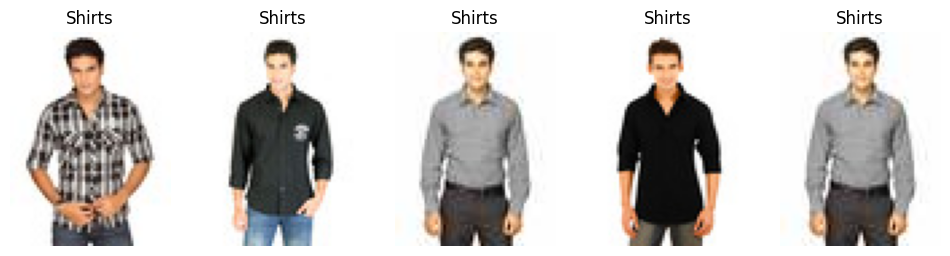


🔹 Similar Items


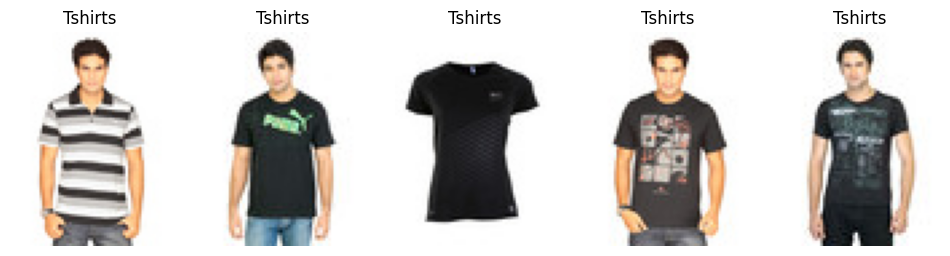

In [ ]:
run_system()